In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv("../data/cleaned/cleaned_telco_churn.csv")

In [78]:
df.head(5)

,customer_i_d,gender,age,married,number_of_dependents,city,zip_code,latitude,longitude,number_of_referrals,...,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason,population
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,not_churned,not_churned,4498
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,not_churned,not_churned,31297
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,62069
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,46677
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,42853


## Target Variable Baseline

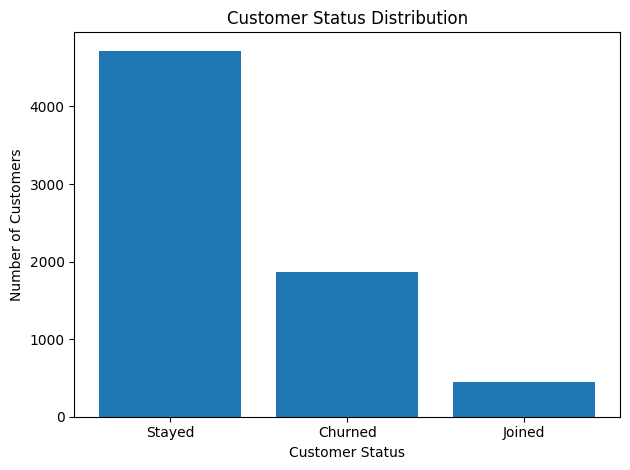

In [181]:
status_counts = df['customer_status'].value_counts()

plt.bar(status_counts.index, status_counts.values)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.title("Customer Status Distribution")

plt.tight_layout()
plt.savefig(
    "../images/Customer_Status_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [80]:
df['churn_flag'] = df['customer_status'].map({'Stayed': 0,'Churned': 1})


### 📌 Observation
The majority of customers are classified as **Stayed**, indicating that most customers continue to use the service. A smaller proportion of customers have **Churned**, while **Joined** customers represent the smallest segment of the customer base.

### 💡 Business Insight
The customer base is largely stable, with retained customers significantly outnumbering churned customers. However, the presence of a considerable number of churned customers highlights an opportunity to improve customer retention. Additionally, the relatively small proportion of newly joined customers suggests that increasing customer acquisition while minimizing churn could help drive long-term business growth.

## Demographics vs Churn

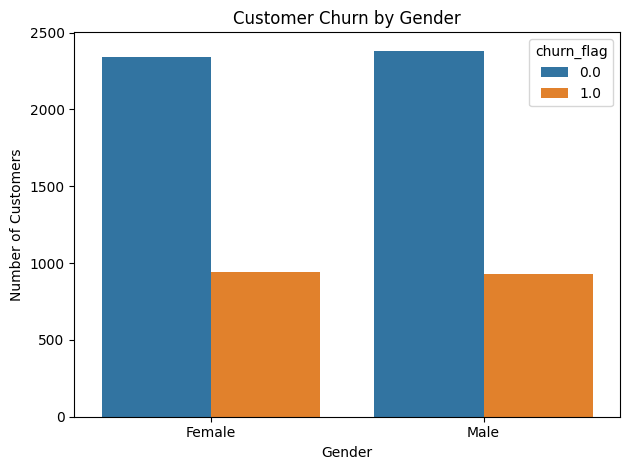

In [182]:
sns.countplot(data=df, x='gender', hue='churn_flag')

plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Customer Churn by Gender")
plt.tight_layout()
plt.savefig(
    "../images/Customer_Churn_by_Gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation
The distribution of **retained** and **churned** customers is nearly identical for both **male** and **female** customers. No substantial difference in customer churn is observed based on gender.

### 💡 Business Insight
Gender does not appear to have a significant association with customer churn. Both male and female customers exhibit similar churn patterns, suggesting that gender alone is unlikely to be a strong predictor of customer attrition. Therefore, retention strategies should prioritize more influential factors such as **contract type**, **tenure**, **monthly charges**, and **service usage** rather than customer gender.

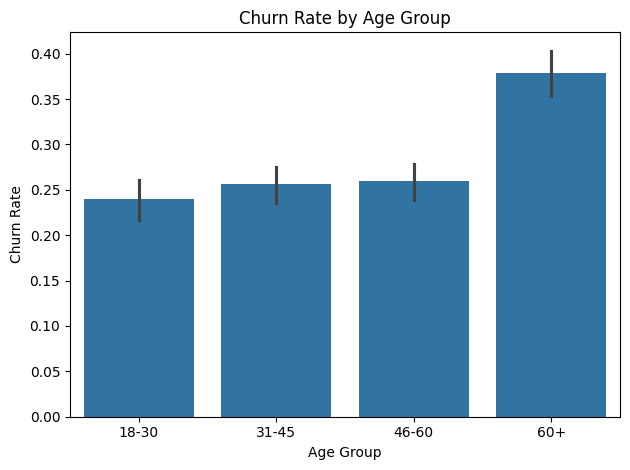

In [183]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)

sns.barplot(data=df, x='age_group', y='churn_flag')

plt.xlabel("Age Group")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Age Group")
plt.tight_layout()
plt.savefig(
    "../images/Churn Rate by Age Group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation
Customers aged **60 years and above** exhibit the **highest churn rate** among all age groups. In contrast, customers aged **18–60 years** show relatively similar churn rates, with only minor differences across these groups.

### 💡 Business Insight
Senior customers (60+) appear to be more likely to discontinue the service compared to younger customers. This suggests that age may be an important factor associated with customer churn. Organizations may consider implementing targeted retention strategies for older customers, such as personalized support, simplified service plans, or loyalty incentives. However, age should be analyzed alongside other variables such as **contract type**, **tenure**, **monthly charges**, and **service usage** before concluding that it is an independent driver of churn.

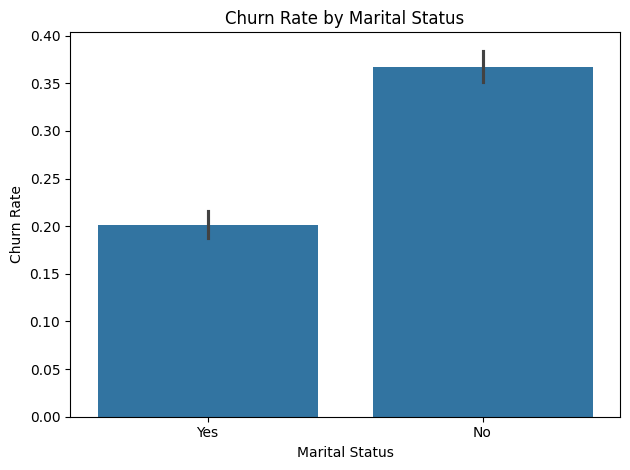

In [184]:
sns.barplot(data=df, x='married', y='churn_flag')

plt.xlabel("Marital Status")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Marital Status")
plt.tight_layout()
plt.savefig(
    "../images/Churn Rate by Marital Status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation
Customers who are **not married** exhibit a significantly **higher churn rate** than customers who are **married**.

### 💡 Business Insight
Marital status appears to be associated with customer retention. Married customers tend to remain with the service for longer, while unmarried customers are more likely to churn. This may indicate differences in service usage, household requirements, or long-term commitment. However, marital status alone should not be considered the sole driver of churn, as other factors such as **contract type**, **tenure**, and **monthly charges** may also influence customer behavior.

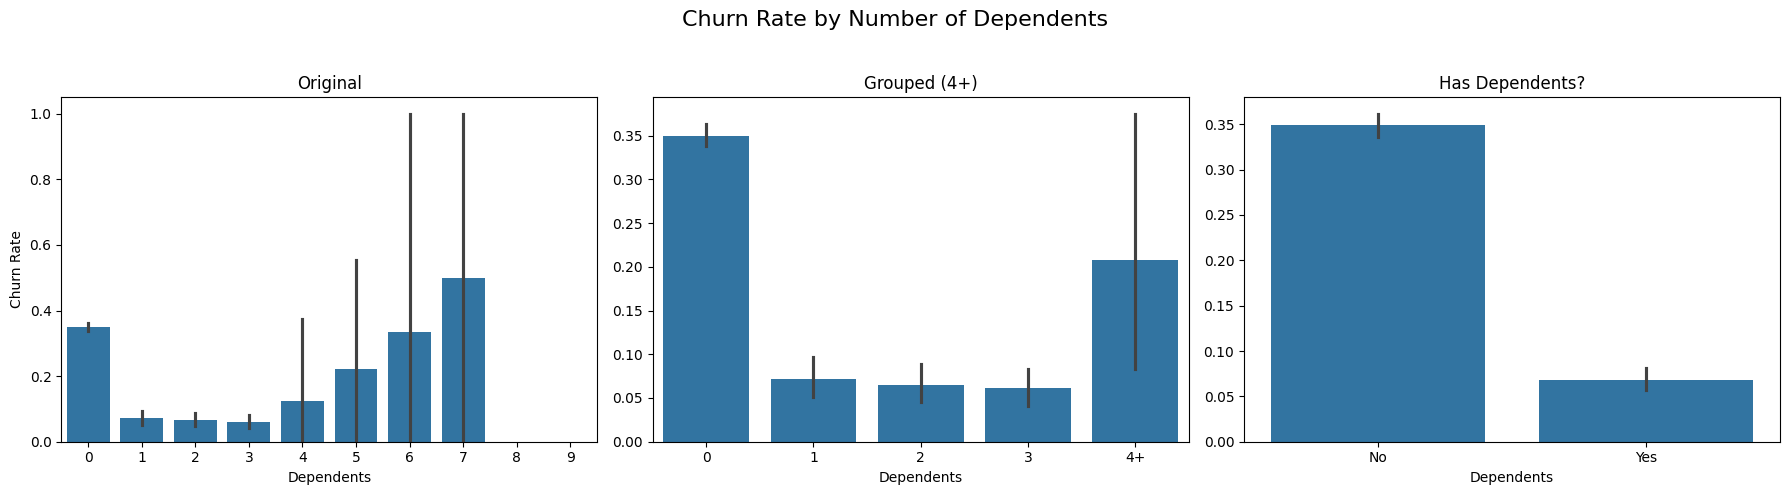

In [185]:
import os

# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Original (0-9 dependents)
sns.barplot(
    data=df,
    x='number_of_dependents',
    y='churn_flag',
    ax=axes[0]
)
axes[0].set_title("Original")
axes[0].set_xlabel("Dependents")
axes[0].set_ylabel("Churn Rate")

# 2. Group 4+
df['dependents_group'] = df['number_of_dependents'].replace({
    4:'4+', 5:'4+', 6:'4+', 7:'4+', 8:'4+', 9:'4+'
}).astype(str)

order = ['0', '1', '2', '3', '4+']

sns.barplot(
    data=df,
    x='dependents_group',
    y='churn_flag',
    order=order,
    ax=axes[1]
)
axes[1].set_title("Grouped (4+)")
axes[1].set_xlabel("Dependents")
axes[1].set_ylabel("")

# 3. Has Dependents vs No Dependents
df['has_dependents'] = df['number_of_dependents'].apply(
    lambda x: 'No' if x == 0 else 'Yes'
)

sns.barplot(
    data=df,
    x='has_dependents',
    y='churn_flag',
    ax=axes[2]
)
axes[2].set_title("Has Dependents?")
axes[2].set_xlabel("Dependents")
axes[2].set_ylabel("")

plt.suptitle("Churn Rate by Number of Dependents", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the entire figure
plt.savefig(
    "../images/Dependents_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation
Customers **without dependents** exhibit a substantially **higher churn rate** than customers **with one or more dependents**. Among customers with dependents, the churn rate remains relatively low regardless of the exact number of dependents.

### 💡 Business Insight
The presence of dependents appears to be associated with **better customer retention**. Customers with dependents may rely more heavily on the service or be less likely to switch providers, resulting in lower churn. This suggests that customers **without dependents** represent a higher-risk segment and may benefit from targeted retention initiatives. However, additional variables such as **contract type**, **tenure**, and **monthly charges** should be considered before concluding that the number of dependents independently drives churn.

## Account & Contract vs Churn

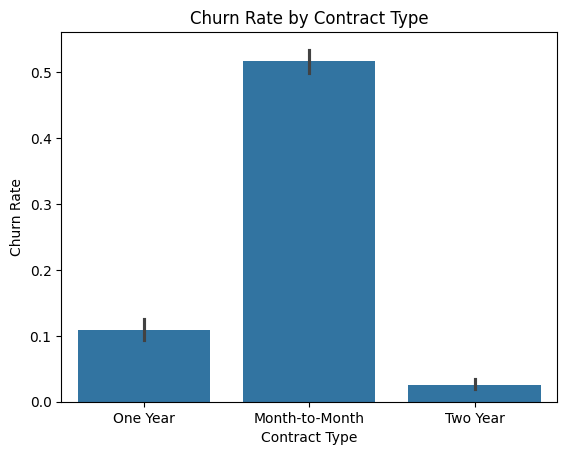

In [186]:
sns.barplot(data=df, x='contract', y='churn_flag')

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.savefig(
    "../images/Churn Rate by Contract Type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation
Customers with **Month-to-Month** contracts exhibit the **highest churn rate**, followed by customers with **One-Year** contracts. Customers with **Two-Year** contracts have the **lowest churn rate**.

### 💡 Business Insight
Contract duration is strongly associated with customer churn. Customers on **Month-to-Month** contracts are more likely to discontinue the service, while those with **longer-term contracts** demonstrate significantly better retention. This suggests that long-term contracts may encourage customer loyalty and reduce the likelihood of churn. However, additional factors such as **monthly charges**, **customer tenure**, and **service satisfaction** should also be considered before concluding that contract type alone drives churn.

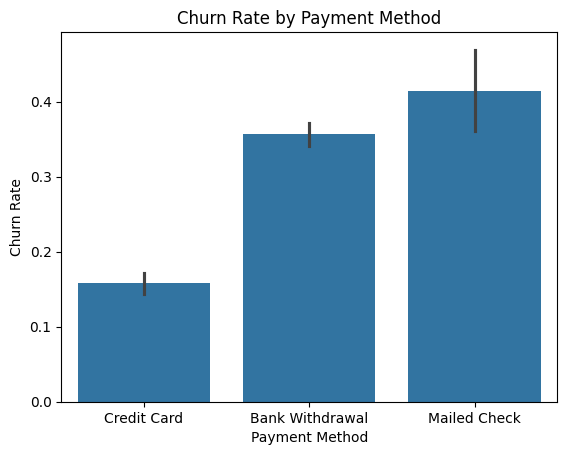

In [187]:
sns.barplot(data=df, x='payment_method', y='churn_flag')

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")

plt.savefig(
    "../images/Churn Rate by Payment Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation
Customers using **Mailed Check** as their payment method have the **highest churn rate**, followed by **Bank Withdrawal**, while customers paying via **Credit Card** exhibit the **lowest churn rate**.

### 💡 Business Insight
The choice of payment method appears to be associated with customer churn. Customers paying through **Mailed Check** are more likely to leave the service, whereas those using **Credit Card** tend to have better retention. This may indicate that customers using automatic or digital payment methods are more engaged or committed. However, payment method alone does not necessarily cause churn and should be analyzed alongside other factors such as **contract type**, **tenure**, and **monthly charges**.

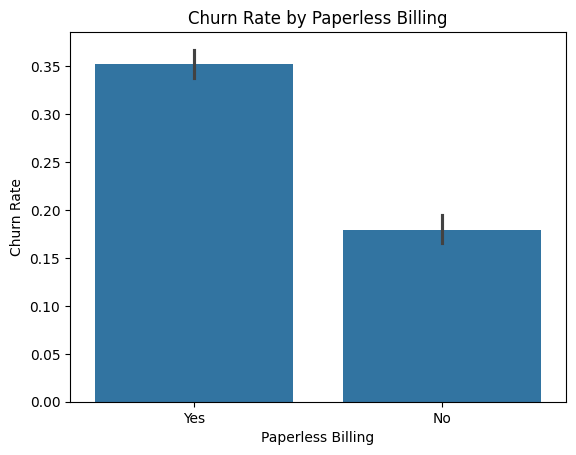

In [188]:
sns.barplot(data=df, x='paperless_billing', y='churn_flag')

plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Paperless Billing")
plt.savefig(
    "../images/Churn Rate by Paperless Billing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation
Customers using paperless billing have a higher churn rate than those who do not.

### 💡 Business Insight
Paperless billing is associated with increased customer churn. This relationship may reflect underlying customer behavior or other related factors rather than a direct cause of churn.

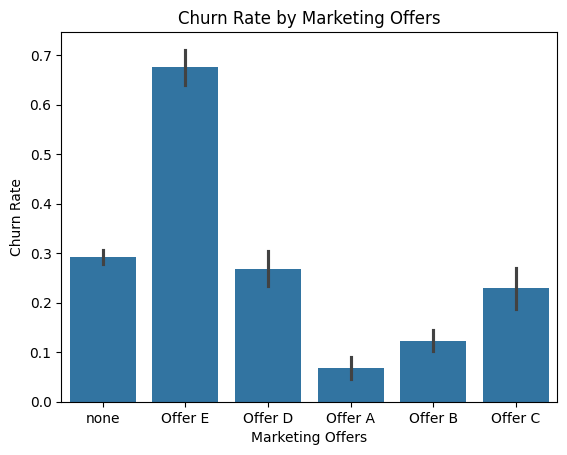

In [189]:
sns.barplot(data=df, x='offer', y='churn_flag')

plt.xlabel("Marketing Offers")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Marketing Offers")
plt.savefig(
    "../images/Churn Rate by Marketing Offers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation
Customers who received **Offer E** exhibit the **highest churn rate** among all marketing offers. In contrast, customers who received **Offer A** have the **lowest churn rate**, followed by **Offer B**. Customers who did not receive any offer or received **Offer C** or **Offer D** show moderate churn rates.

### 💡 Business Insight
The effectiveness of marketing offers appears to vary considerably. Customers receiving **Offer A** and **Offer B** demonstrate lower churn rates, suggesting these offers may be more successful in improving customer retention. Conversely, the high churn rate among customers associated with **Offer E** may indicate that the offer is less effective or is primarily targeted at customers who are already at a high risk of churning. Further investigation is required to determine whether the observed churn is due to the offer itself or the characteristics of the customers who received it.

## Tenure & Revenue vs Churn

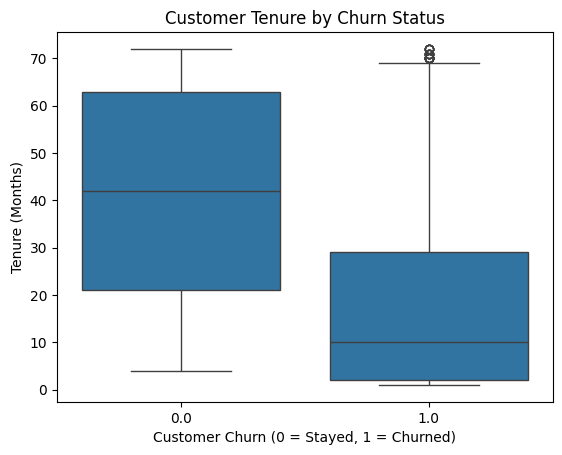

In [190]:
sns.boxplot(data=df,x='churn_flag',y='tenure_in_months')
plt.xlabel("Customer Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Tenure (Months)")
plt.title("Customer Tenure by Churn Status")
plt.savefig(
    "../images/Customer Tenure by Churn Status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation
Customers who churn have a significantly lower median tenure than customers who remain with the company. Most churned customers leave within the first few months of service, whereas retained customers generally have much longer tenures.

### 💡 Business Insight
Customer churn is concentrated among newer customers, indicating that the early stages of the customer lifecycle represent the highest-risk period. This suggests that onboarding, customer engagement, and retention initiatives should be prioritized during the first year of service to reduce early customer attrition.

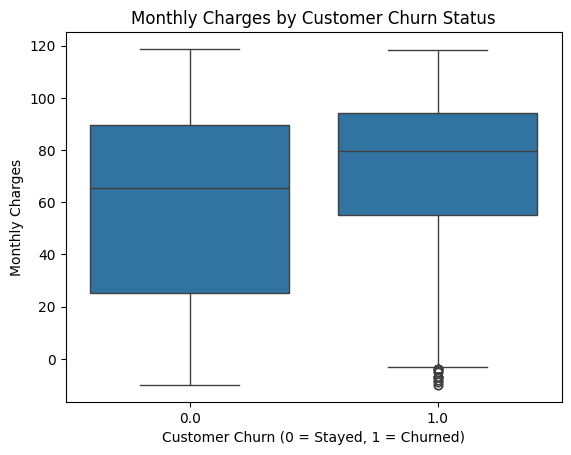

In [191]:
sns.boxplot(data=df, x='churn_flag', y='monthly_charge')

plt.xlabel("Customer Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges by Customer Churn Status")
plt.savefig(
    "../images/Monthly Charges by Customer Churn Status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [91]:
# Replace missing monthly charge values with the median to preserve the dataset
median_charge = df.loc[df['monthly_charge'] >= 0, 'monthly_charge'].median()

df['monthly_charge'] = df['monthly_charge'].fillna(median_charge)

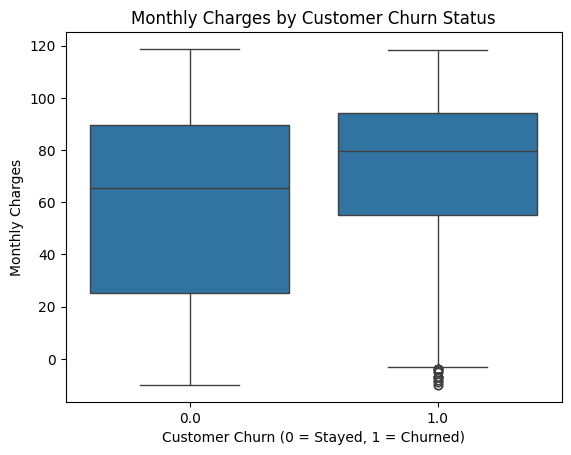

In [92]:
sns.boxplot(data=df, x='churn_flag', y='monthly_charge')

plt.xlabel("Customer Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges by Customer Churn Status")

plt.show()

### 📌 Observation

- Customers who **churned** have a higher median **monthly charge** than customers who stayed.
- The monthly charges of churned customers are concentrated toward the higher end of the pricing range, whereas retained customers exhibit a wider spread of monthly charges.
- A few negative monthly charge values appear as outliers in the churned group, indicating potential data quality issues or billing adjustments.

### 💡 Business Insight

Customers with higher monthly charges are more likely to churn, suggesting that pricing or perceived value may influence customer retention. The company should closely monitor customers with high monthly bills and consider personalized discounts, loyalty rewards, or value-added service bundles to reduce churn. However, monthly charges should be analyzed alongside factors such as contract type, tenure, and service quality before drawing causal conclusions.

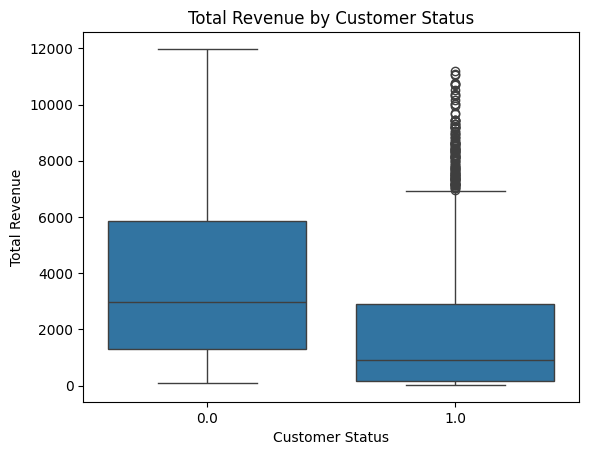

In [192]:
sns.boxplot(data=df,x='churn_flag',y='total_revenue')
plt.xlabel("Customer Status")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Customer Status")
plt.savefig(
    "../images/Total Revenue by Customer Status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Observation

- Customers who **stayed** have a noticeably higher median **total revenue** than customers who churned.
- The distribution of total revenue is much wider for retained customers, indicating that long-term customers contribute significantly more revenue over time.
- Although a few churned customers generated high revenue, most churned customers have relatively lower lifetime revenue.

### 💡 Business Insight

Retained customers generate greater lifetime revenue due to their longer relationship with the company. Improving customer retention, especially during the early stages of the customer lifecycle, can increase customer lifetime value (CLV) and maximize long-term business revenue.

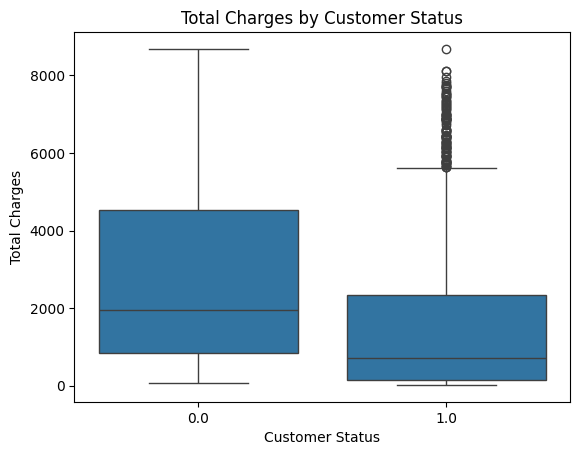

In [193]:
sns.boxplot(data=df,x='churn_flag',y='total_charges')
plt.xlabel("Customer Status")
plt.ylabel("Total Charges")
plt.title("Total Charges by Customer Status")
plt.savefig(
    "../images/Total Charges by Customer Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation

- Customers who **stayed** have substantially higher median **total charges** compared to customers who churned.
- Churned customers generally accumulate lower total charges, suggesting they leave before making significant long-term payments.
- The retained customer group also exhibits a wider range of total charges, reflecting varying levels of long-term service usage.

### 💡 Business Insight

Customers who remain with the company tend to generate higher cumulative revenue through continued service usage. Reducing early customer churn can increase total customer spending over time and improve overall business profitability.

In [95]:
df.head()

,customer_i_d,gender,age,married,number_of_dependents,city,zip_code,latitude,longitude,number_of_referrals,...,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason,population,churn_flag,age_group,dependents_group,has_dependents
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,381.51,974.81,Stayed,not_churned,not_churned,4498,0.0,31-45,0,No
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,96.21,610.28,Stayed,not_churned,not_churned,31297,0.0,46-60,0,No
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,134.60,415.45,Churned,Competitor,Competitor had better devices,62069,1.0,46-60,0,No
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,46677,1.0,60+,0,No
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,22.14,289.54,Churned,Dissatisfaction,Network reliability,42853,1.0,60+,0,No


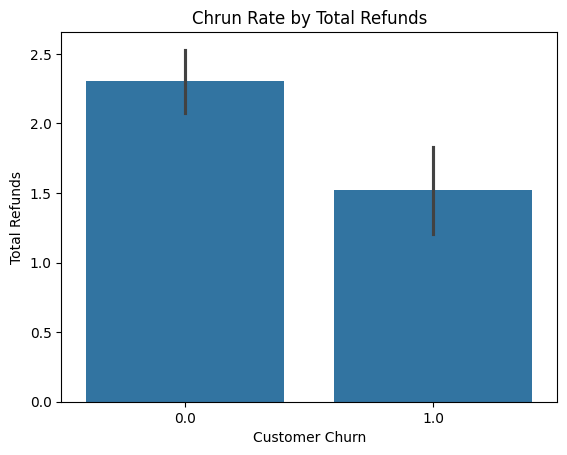

In [194]:
sns.barplot(data=df, x='churn_flag', y='total_refunds')

plt.xlabel("Customer Churn")
plt.ylabel("Total Refunds")
plt.title("Chrun Rate by Total Refunds")
plt.savefig(
    "../images/Chrun Rate by Total Refunds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Observation

- Customers who **stayed** received a higher average **total refund amount** than customers who churned.
- On average, retained customers have greater total refunds, although the difference between the two groups is relatively small.
- This suggests that refunds are not exclusively associated with customers who eventually churn.

### 💡 Business Insight

Providing refunds or billing adjustments does not necessarily lead to customer churn. In some cases, resolving billing issues through refunds may help retain customers by improving customer satisfaction. However, further analysis is required to determine whether refunds are driven by customer tenure, billing disputes, or other service-related factors.

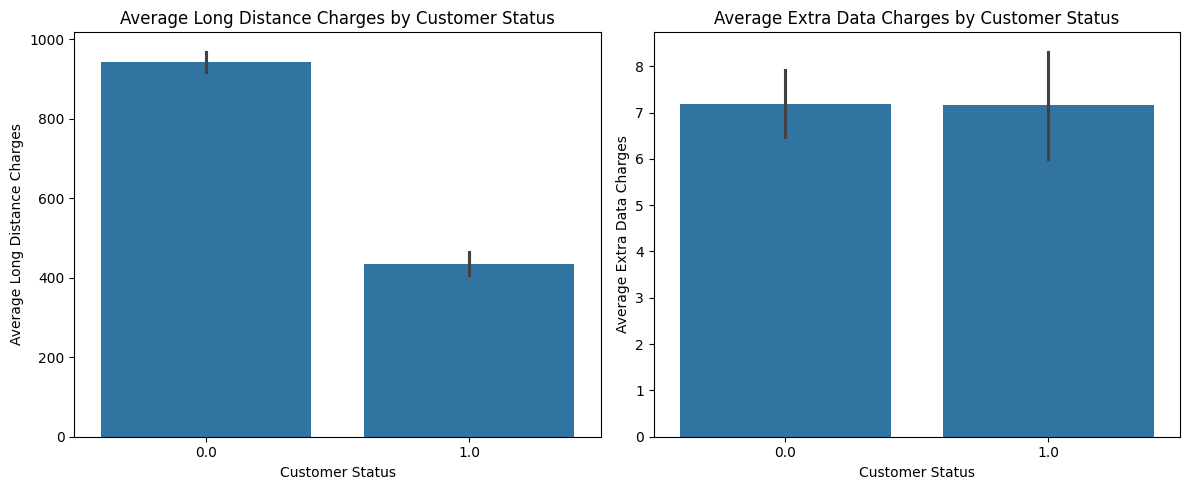

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df,x='churn_flag',y='total_long_distance_charges',ax=axes[0])

axes[0].set_xlabel("Customer Status")
axes[0].set_ylabel("Average Long Distance Charges")
axes[0].set_title("Average Long Distance Charges by Customer Status")

sns.barplot(data=df,x='churn_flag',y='total_extra_data_charges',ax=axes[1])
            
axes[1].set_xlabel("Customer Status")
axes[1].set_ylabel("Average Extra Data Charges")
axes[1].set_title("Average Extra Data Charges by Customer Status")

plt.tight_layout()
plt.savefig(
    "../images/Average Long Distance Charges and Average Extra Data Charges by Customer Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- Customers who **stayed** have significantly higher average **long-distance charges** than customers who churned.
- Churned customers incur less than half the average long-distance charges of retained customers, indicating lower long-distance service usage.
- In contrast, the average **extra data charges** are nearly identical for both churned and retained customers, showing little to no noticeable difference between the two groups.

---

## 💡 Business Insight

Higher long-distance charges are associated with customers who remain with the company, suggesting that customers who actively use long-distance services tend to have stronger engagement and longer customer relationships. Offering targeted long-distance plans or bundled communication services may help improve customer retention.

On the other hand, **extra data charges do not appear to differentiate churned and retained customers**, indicating that excess data usage alone is not a strong indicator of churn. Therefore, extra data charges are likely to provide limited predictive value on their own and should be analyzed alongside other factors such as contract type, tenure, monthly charges, and value-added services.

### Services vs Churn

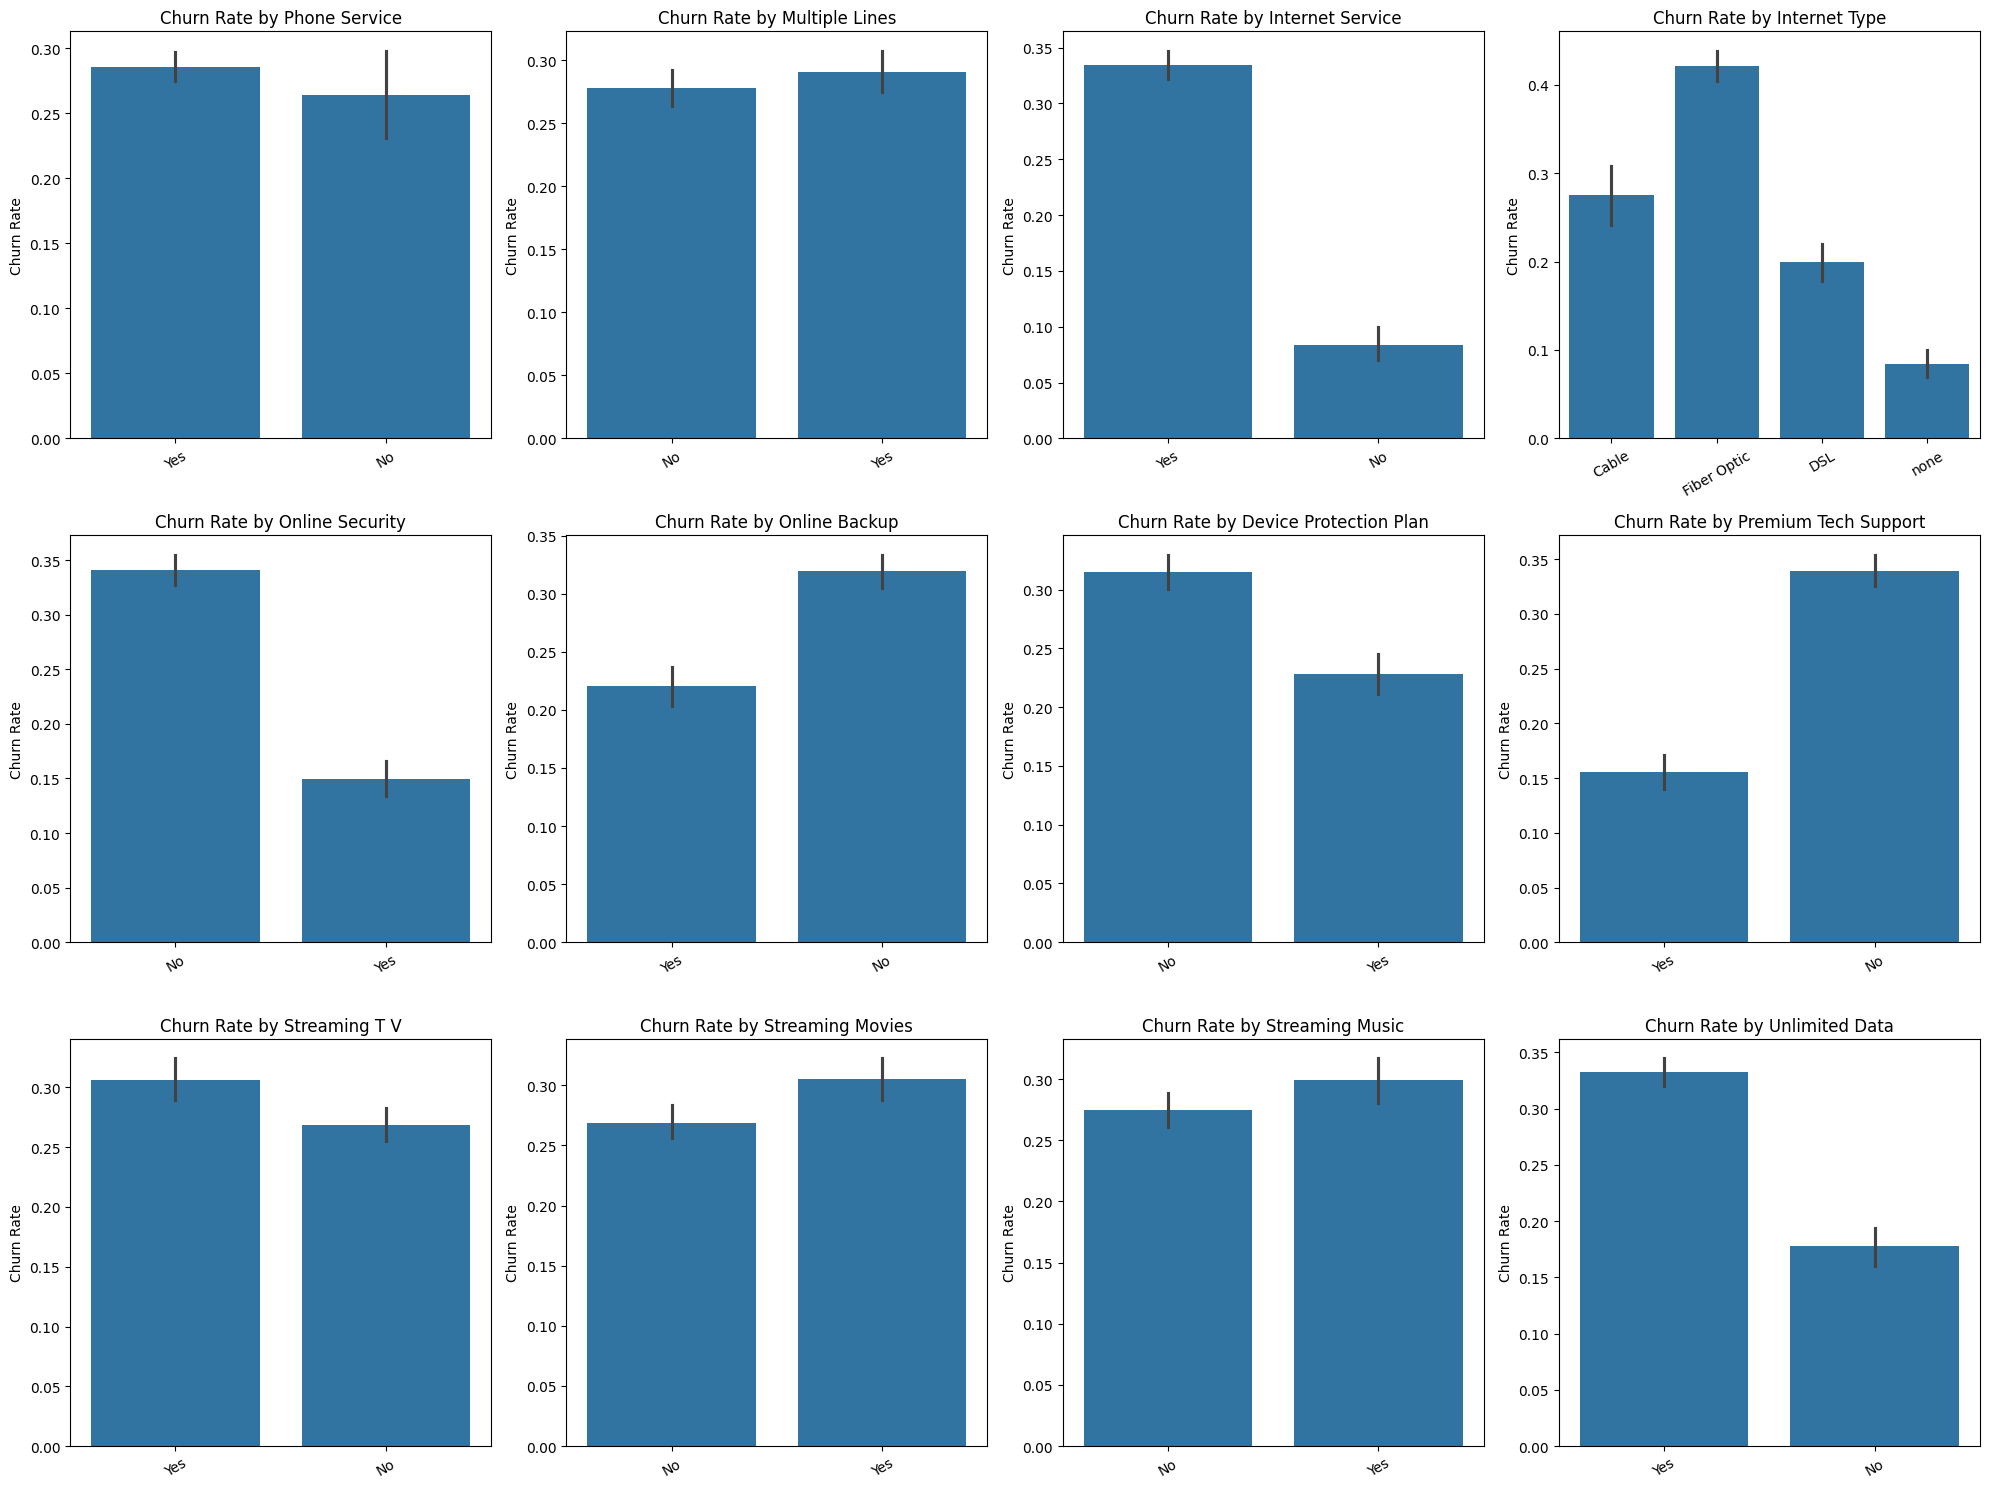

In [196]:
service_cols = [
    'phone_service',
    'multiple_lines',
    'internet_service',
    'internet_type',
    'online_security',
    'online_backup',
    'device_protection_plan',
    'premium_tech_support',
    'streaming_t_v',
    'streaming_movies',
    'streaming_music',
    'unlimited_data'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    sns.barplot(
        data=df,
        x=col,
        y='churn_flag',
        ax=axes[i]
    )

    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.savefig(
    "../images/Internet_and_Service_Features_vs_Churn.png.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- Customers with **Fiber Optic** internet service exhibit the highest churn rate, while customers with **DSL** or **no internet service** have considerably lower churn.
- Customers **without Online Security** have a substantially higher churn rate than those who subscribe to the service.
- Customers **without Premium Tech Support** also show significantly higher churn compared to customers who have technical support.
- A similar pattern is observed for **Device Protection Plan**, where customers without protection are more likely to churn.
- Customers **without Online Backup** experience higher churn than those who use the service.
- Customers with **Unlimited Data** have a higher churn rate than those without unlimited data, indicating that this feature alone does not guarantee customer retention.
- Phone Service, Multiple Lines, Streaming TV, Streaming Movies, and Streaming Music show relatively small differences in churn rates, suggesting they have a weaker association with customer churn.

---

## 💡 Business Insight

The strongest churn associations are observed among customers who **lack value-added support services**, particularly **Online Security**, **Premium Tech Support**, **Online Backup**, and **Device Protection Plan**. These services appear to enhance customer engagement and retention. The company should target customers who have not adopted these services with personalized bundles, promotional offers, or free trials to increase service adoption and potentially reduce churn.

Additionally, customers using **Fiber Optic Internet** represent a high-risk segment for churn. This group should be further analyzed to determine whether pricing, service quality, network reliability, or customer expectations contribute to the higher churn rate. Addressing these underlying issues could significantly improve customer retention.

While streaming-related services and phone features show only minor differences in churn, they may still provide incremental value when combined with other retention-focused service bundles. Since these observations are based on exploratory analysis, further statistical testing and predictive modeling should be conducted to quantify each service's independent impact while controlling for factors such as contract type, tenure, and monthly charges.

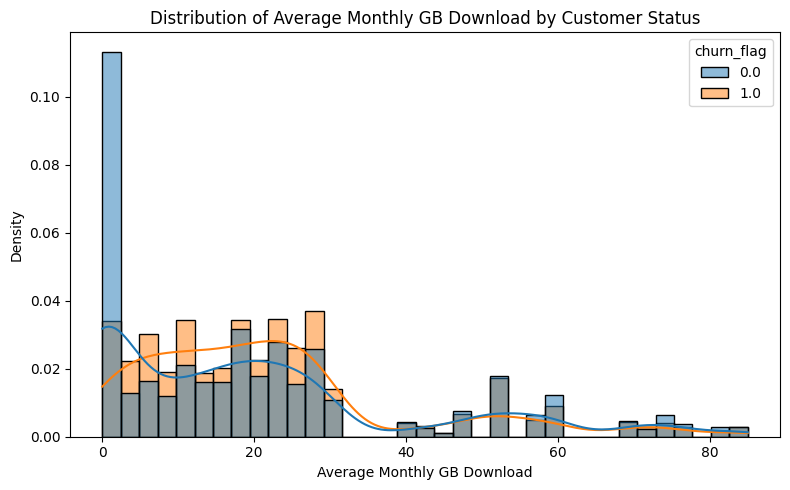

In [199]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='avg_monthly_g_b_download',
    hue='churn_flag',
    kde=True,
    stat='density',
    common_norm=False
)

plt.xlabel("Average Monthly GB Download")
plt.ylabel("Density")
plt.title("Distribution of Average Monthly GB Download by Customer Status")

plt.tight_layout()

plt.savefig(
    "../images/Distribution_of_Average_Monthly_GB_Download_by_Customer_Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- A large proportion of **retained customers** have very low average monthly download usage (around 0–5 GB), resulting in a pronounced peak at the lower end of the distribution.
- **Churned customers** are more concentrated in the **10–30 GB** usage range, indicating moderate internet usage.
- Both customer groups contain a smaller number of heavy internet users (above 40 GB), with substantial overlap between the distributions.
- Overall, the download usage distributions overlap considerably, suggesting that average monthly download alone is not a strong discriminator of customer churn.

---

## 💡 Business Insight

Average monthly internet usage appears to have **some association** with customer churn, but the relationship is not strong enough to explain churn on its own. Customers with moderate usage levels seem to churn more frequently than very low-usage customers, while heavy users are present in both groups. This indicates that internet usage should be analyzed alongside other important factors such as contract type, monthly charges, tenure, internet service type, and value-added services to better understand customer churn behavior.

## Geography vs Churn

In [102]:
city_churn = (df.groupby('city')['churn_flag'].mean().sort_values(ascending=False).head(10))

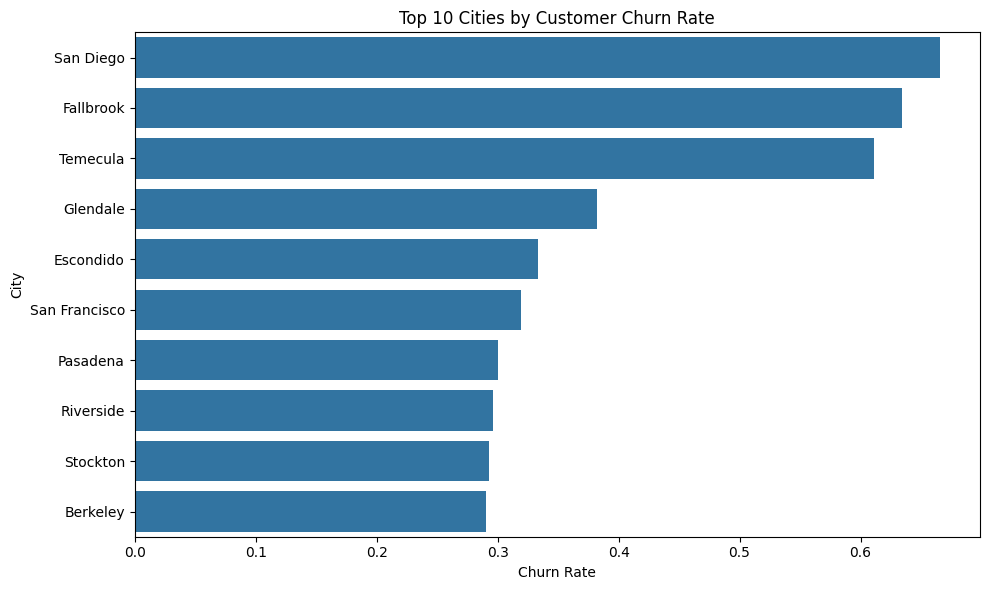

In [201]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_churn,
    x='churn_rate',
    y='city'
)

plt.xlabel("Churn Rate")
plt.ylabel("City")
plt.title("Top 10 Cities by Customer Churn Rate")

plt.tight_layout()

plt.savefig(
    "../images/Top_10_Cities_by_Customer_Churn_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

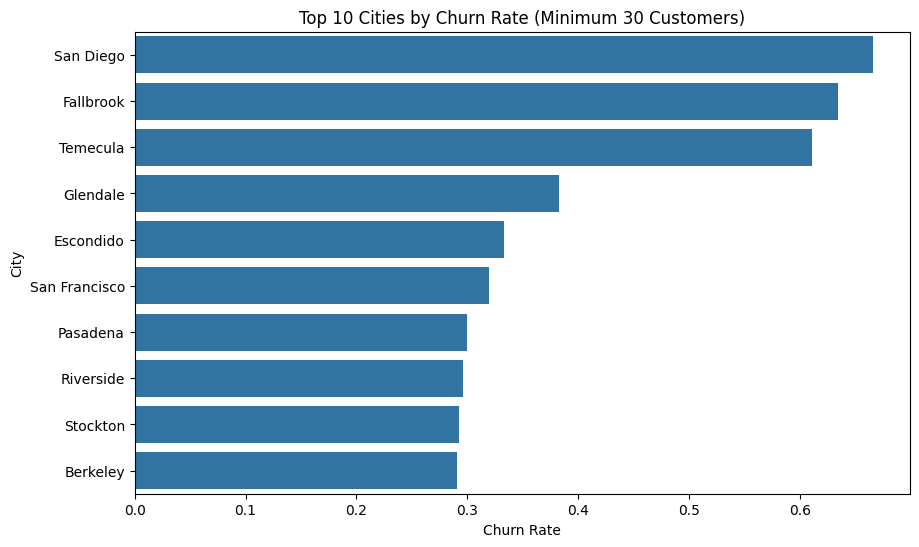

In [202]:
city_churn = (
    df.groupby('city')
      .agg(
          churn_rate=('churn_flag', 'mean'),
          customers=('customer_i_d', 'count')
      )
)

city_churn = (
    city_churn[city_churn['customers'] >= 30]
    .sort_values('churn_rate', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_churn,
    x='churn_rate',
    y=city_churn.index
)

plt.xlabel("Churn Rate")
plt.ylabel("City")
plt.title("Top 10 Cities by Churn Rate (Minimum 30 Customers)")

plt.savefig(
    "../images/Top 10 Cities by Churn Rate (Minimum 30 Customers).png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 📌 Observation

- Among cities with at least **30 customers**, **San Diego** exhibits the highest churn rate, followed by **Fallbrook** and **Temecula**.
- These cities have substantially higher churn rates than the remaining cities in the top 10, indicating notable geographic variation in customer retention.
- Cities such as **Berkeley**, **Stockton**, and **Riverside** have comparatively lower churn rates within the top-ranked cities, although they still experience moderate customer churn.

---

## 💡 Business Insight

The variation in churn rates across cities suggests that geographic factors may influence customer retention. High-churn cities such as **San Diego**, **Fallbrook**, and **Temecula** should be prioritized for further investigation to identify underlying causes, including network performance, local competition, service quality, pricing strategies, or customer demographics. Location-specific retention campaigns and service improvements in these high-risk regions could help reduce customer churn and improve overall retention.

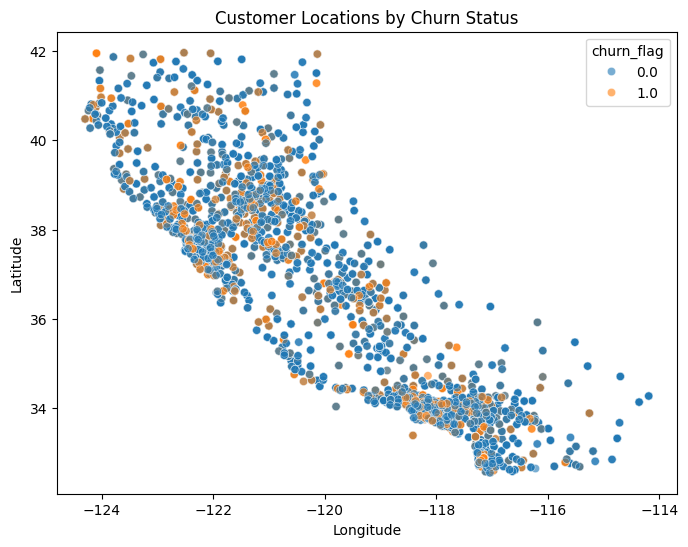

In [203]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='churn_flag',
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer Locations by Churn Status")

plt.savefig(
    "../images/Customer Locations by Churn Status).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- Customer locations are distributed throughout California, with higher concentrations around major metropolitan regions.
- Churned and retained customers are geographically dispersed and exhibit substantial overlap across the state.
- No distinct geographic clusters of churn are visible from the scatter plot, indicating that customer churn is not concentrated within a specific geographic area.
- The spatial distribution suggests that customers from both churn groups are served across similar locations.

---

## 💡 Business Insight

Geographic location alone does not appear to be a strong predictor of customer churn. While customer density varies across the state, churned and retained customers are widely intermingled, suggesting that churn is more strongly influenced by customer-specific factors such as contract type, tenure, monthly charges, internet service type, and value-added services. Geographic information can still provide additional business context and is better explored through interactive maps (e.g., Power BI) to identify localized operational or service-quality issues.

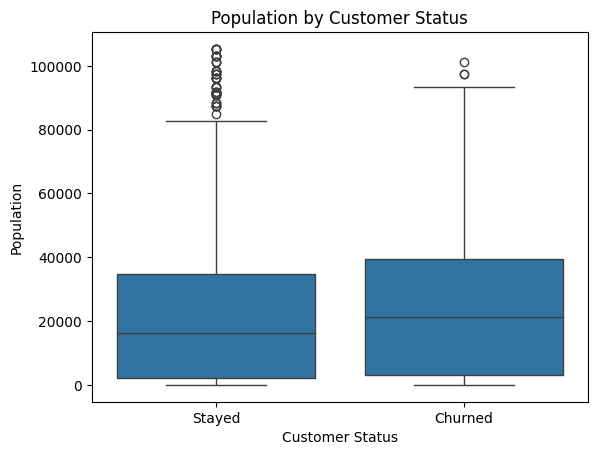

In [204]:
sns.boxplot(data=df,x='churn_flag',y='population')

plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel("Customer Status")
plt.ylabel("Population")
plt.title("Population by Customer Status")

plt.savefig(
    "../images/Population by Customer Status).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- Customers who churned have a slightly higher median city population than customers who stayed.
- Both customer groups exhibit a wide distribution of population values with substantial overlap.
- Several outliers are present in both groups, representing customers from highly populated cities.
- Overall, the distributions are very similar, indicating only a weak relationship between city population and customer churn.

---

## 💡 Business Insight

The population of a customer's city does not appear to be a strong differentiating factor for customer churn. Since both churned and retained customers are distributed across cities of varying population sizes, customer churn is likely driven more by service-related and customer-specific factors such as contract type, tenure, monthly charges, internet service, and value-added services rather than the population of the customer's location.

## Churn Reason/Category (churned customers ONLY)

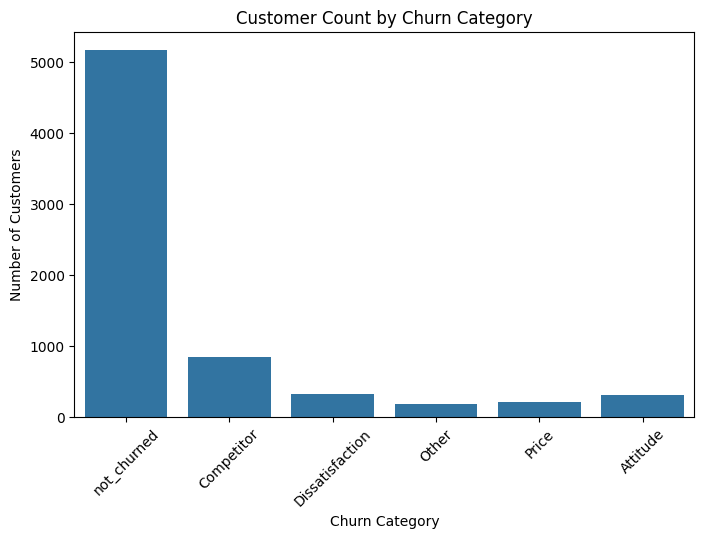

In [205]:
plt.figure(figsize=(8, 5))

order = df['churn_category'].value_counts().index

sns.countplot(data=df,x='churn_category')

plt.xticks(rotation=45)
plt.xlabel("Churn Category")
plt.ylabel("Number of Customers")
plt.title("Customer Count by Churn Category")

plt.savefig(
    "../images/Customer Count by Churn Category).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- The majority of customers belong to the **"Not Churned"** category, indicating that most customers remained with the company during the observation period.
- Among customers who churned, **Competitor** is the most frequently reported reason for leaving.
- **Dissatisfaction** and **Attitude** are the next most common churn categories, while **Price** and **Other** account for a smaller proportion of churn cases.
- The distribution suggests that customer churn is driven by multiple factors, with competitive pressure being the most prominent.

---

## 💡 Business Insight

The analysis indicates that **competition is the leading reason for customer churn**, suggesting that customers may be switching to providers offering better pricing, service quality, or promotional benefits. The company should strengthen its competitive positioning through improved value propositions, targeted retention offers, and differentiated service plans.

Additionally, churn related to **Dissatisfaction** and **Attitude** highlights opportunities to improve customer experience through better service quality, faster issue resolution, and enhanced customer support. Addressing these operational factors alongside competitive strategies can help reduce overall churn and improve long-term customer retention.

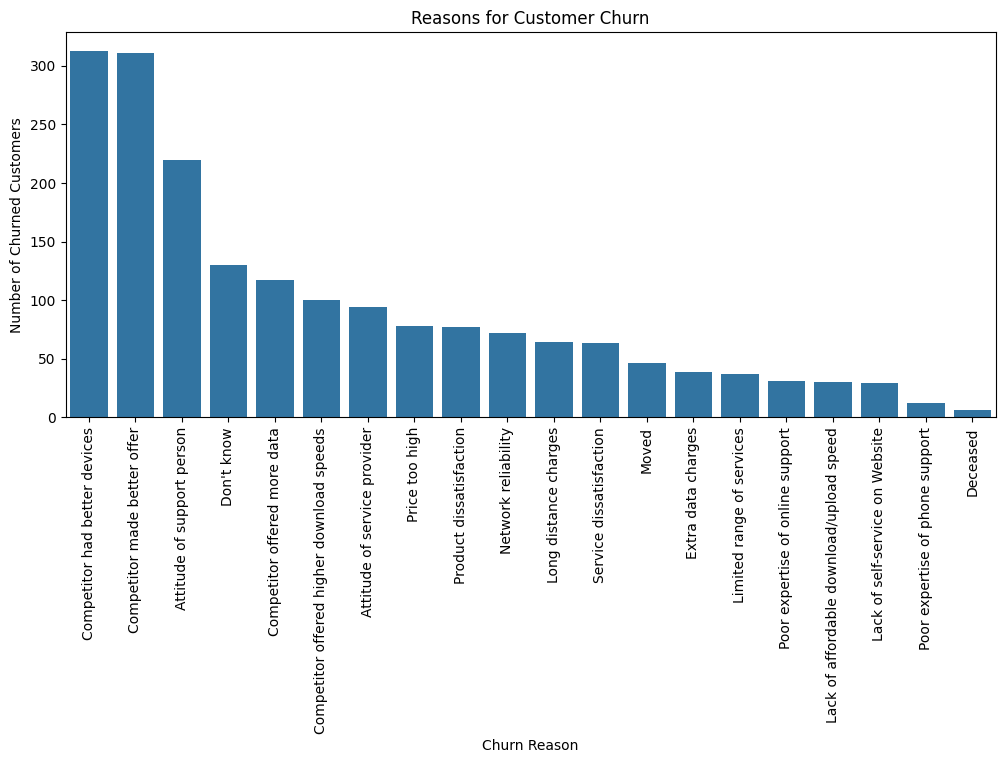

In [206]:
plt.figure(figsize=(12, 5))

churn_reason = df[df['churn_reason'] != 'not_churned']

order = churn_reason['churn_reason'].value_counts().index

sns.countplot(
    data=churn_reason,
    x='churn_reason',
    order=order
)

plt.xticks(rotation=90)
plt.xlabel("Churn Reason")
plt.ylabel("Number of Churned Customers")
plt.title("Reasons for Customer Churn")

plt.savefig(
    "../images/Reasons for Customer Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- The most common reasons for customer churn are **Competitor had better devices** and **Competitor made a better offer**, making competition the dominant driver of customer attrition.
- Customer service-related issues, particularly **Attitude of Support Person** and **Attitude of Service Provider**, are also significant contributors to churn.
- Other notable reasons include **Competitor offered more data**, **Competitor offered higher download speeds**, and **Price too high**, suggesting that customers are influenced by both service quality and perceived value.
- Technical and operational issues such as **Network Reliability**, **Service Dissatisfaction**, **Long Distance Charges**, and **Extra Data Charges** contribute to churn but occur less frequently.
- Reasons such as **Poor Expertise of Phone Support**, **Poor Expertise of Online Support**, and **Deceased** account for only a small proportion of churn cases.

---

## 💡 Business Insight

The analysis indicates that **competitive pressure is the primary reason customers switch providers**. To reduce churn, the company should strengthen its competitive positioning by offering attractive pricing, device upgrade programs, larger data plans, and faster internet packages.

Additionally, improving **customer support quality** and employee training can address churn caused by poor service experiences. Monitoring customer complaints related to pricing, network reliability, and service satisfaction can help identify at-risk customers early and enable targeted retention strategies before they decide to switch to a competitor.

## Correlation Heatmap

In [157]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [158]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded['age_group'] = le.fit_transform(df_encoded['age_group'])

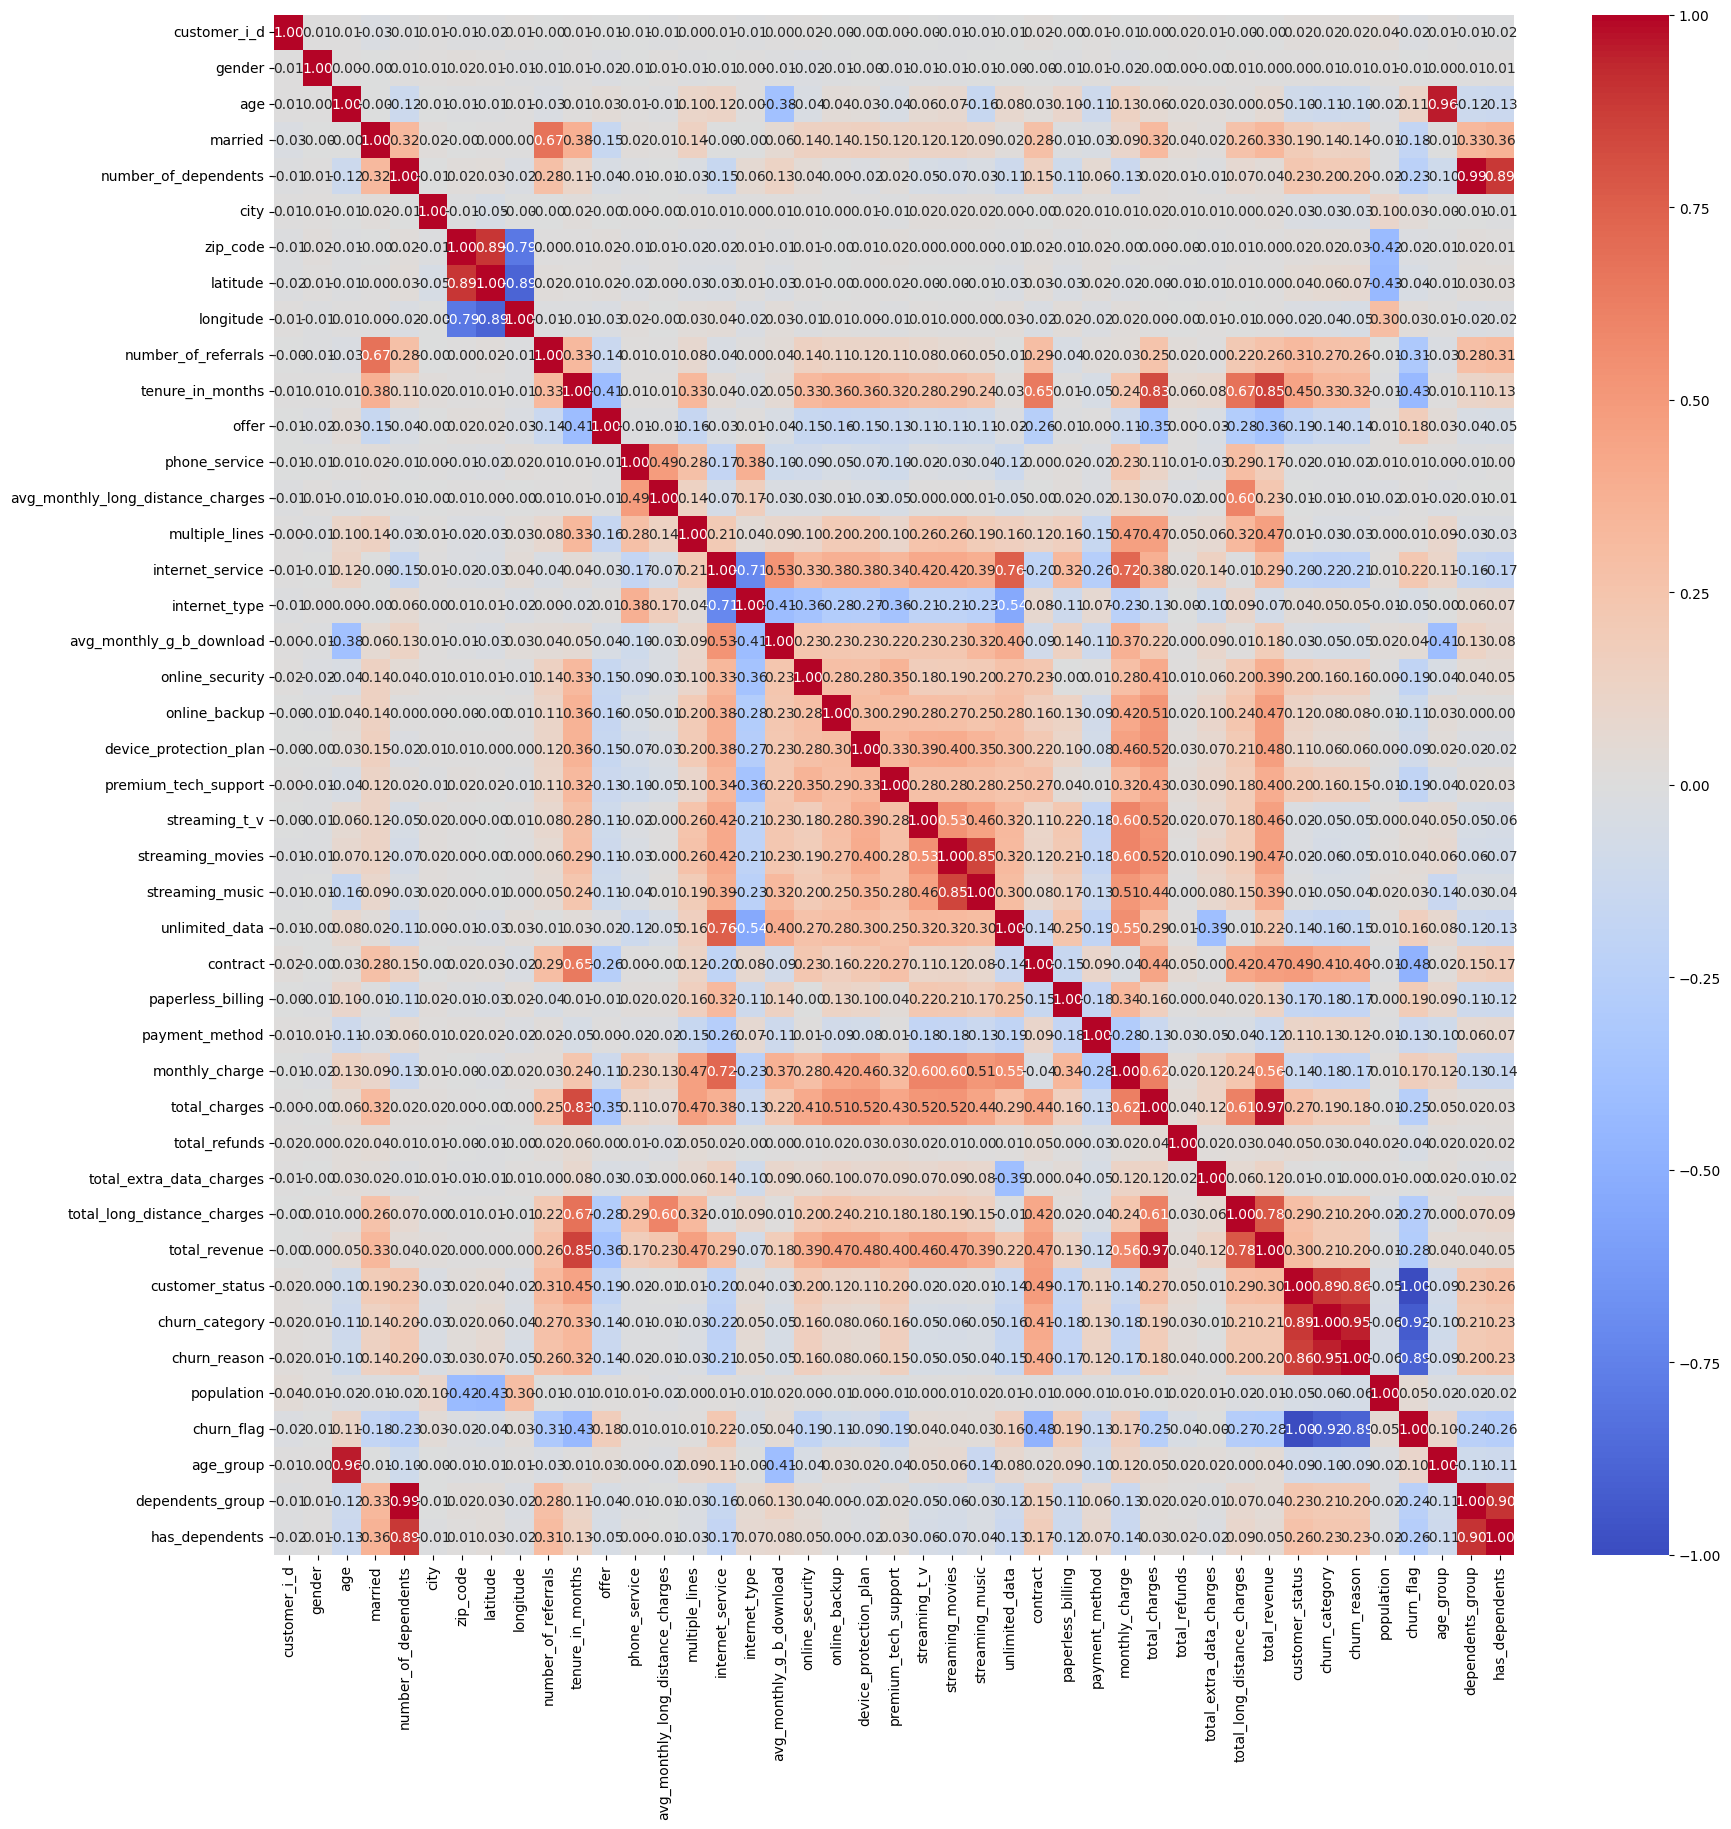

In [207]:
corr = df_encoded.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')

plt.savefig(
    "../images/Correlation_Matrix_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

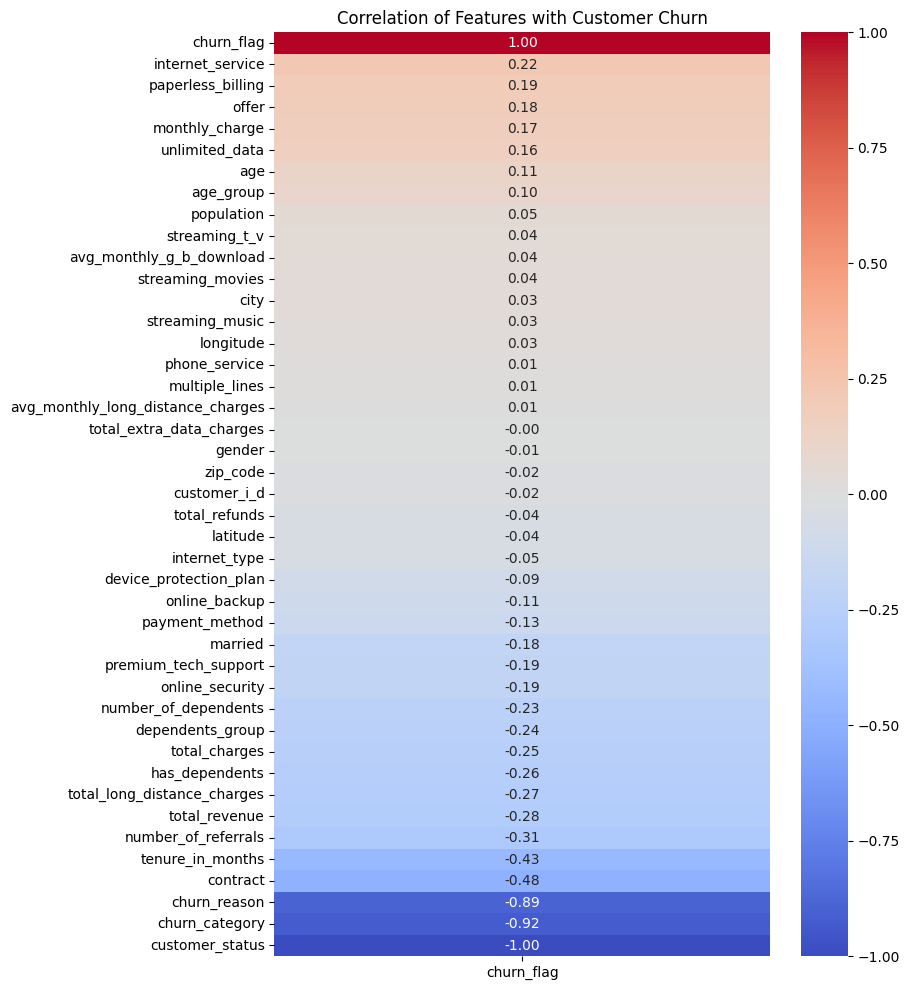

In [208]:
plt.figure(figsize=(8, 12))

corr_target = (
    df_encoded.corr()[['churn_flag']]
    .sort_values(by='churn_flag', ascending=False)
)

sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation of Features with Customer Churn")

plt.savefig(
    "../images/Feature_Correlation_with_Churn_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observation

- The correlation heatmap reveals both relationships between features and their association with customer churn.
- Contract length (-0.48) and tenure (-0.43) show the strongest negative correlations with churn, indicating that long-term customers are significantly less likely to leave.
- Monthly charges (0.17), paperless billing (0.19), and internet service (0.22) exhibit weak positive associations with churn.
- Strong correlations exist among Total Revenue, Total Charges, and Tenure, reflecting natural customer lifecycle relationships rather than independent churn drivers.
- Features such as Gender, City, and Phone Service show negligible correlations with churn.

---

## 💡 Business Insight

Long-term customer relationships are the strongest indicator of retention. Customers on longer contracts, with higher tenure, referrals, and value-added services such as Online Security and Premium Tech Support demonstrate substantially lower churn rates. Conversely, customers with higher monthly charges and internet-related services exhibit slightly higher churn, suggesting opportunities for pricing optimization and targeted retention initiatives.

The heatmap also identifies highly correlated feature pairs, which is useful during feature selection to reduce redundancy and avoid multicollinearity in predictive models.

## Profile Comparison Table

In [168]:
profile_summary = (df.groupby('customer_status').mean(numeric_only=True).round(2).T)

profile_summary

customer_status,Churned,Joined,Stayed
age,49.74,42.87,45.58
number_of_dependents,0.12,0.36,0.62
zip_code,93435.75,93407.21,93513.58
latitude,36.03,36.16,36.27
longitude,-119.67,-119.74,-119.79
number_of_referrals,0.52,0.95,2.61
tenure_in_months,17.98,1.72,41.04
avg_monthly_long_distance_charges,23.17,22.30,22.94
avg_monthly_g_b_download,22.18,15.28,20.36
monthly_charge,73.35,42.78,61.74


## 📌 Observation

- Stayed customers exhibit the highest average tenure (41.04 months), total revenue ($3,735.68), total charges ($2,788.52), and referral count (2.61), indicating stronger long-term engagement.
- Churned customers have the highest average monthly charges ($73.35) despite shorter tenure (17.98 months), suggesting pricing may be associated with customer attrition.
- Customers with more dependents are more likely to remain with the company, while churned customers report the fewest dependents.
- Newly joined customers naturally have the lowest tenure, revenue, and accumulated charges because they are in the early stages of their customer lifecycle.
- Geographic variables (ZIP code, latitude, longitude, and population) show relatively small differences across customer groups.

---

## 💡 Business Insight

The customer profile comparison reveals that long-term engagement is closely associated with customer retention. Retained customers contribute significantly more lifetime revenue, refer more new customers, and remain with the company for substantially longer periods. In contrast, churned customers pay higher monthly charges while exhibiting lower tenure and engagement. These findings suggest that improving early customer experiences, encouraging referrals, and optimizing pricing strategies could help reduce churn and increase customer lifetime value.